In [1]:
# 데이터 로드
from sklearn.datasets import fetch_olivetti_faces

olivetti = fetch_olivetti_faces()

In [2]:
# 데이터, 정답 생성
X = olivetti.data
y = olivetti.target

In [3]:
# 데이터 분할
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.4, random_state=42)

In [4]:
# 연산속도 높이기 pca
from sklearn.decomposition import PCA

pca = PCA(n_components=0.99)
x_train_pca = pca.fit_transform(x_train)
x_test_pca = pca.transform(x_test)
pca.n_components_

np.int64(177)

c:\Users\Playdata\AppData\Local\miniconda3\envs\new_01\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Playdata\AppData\Local\miniconda3\envs\new_01\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Playdata\AppData\Local\miniconda3\envs\new_01\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Playdata\AppData\Local\miniconda3\env

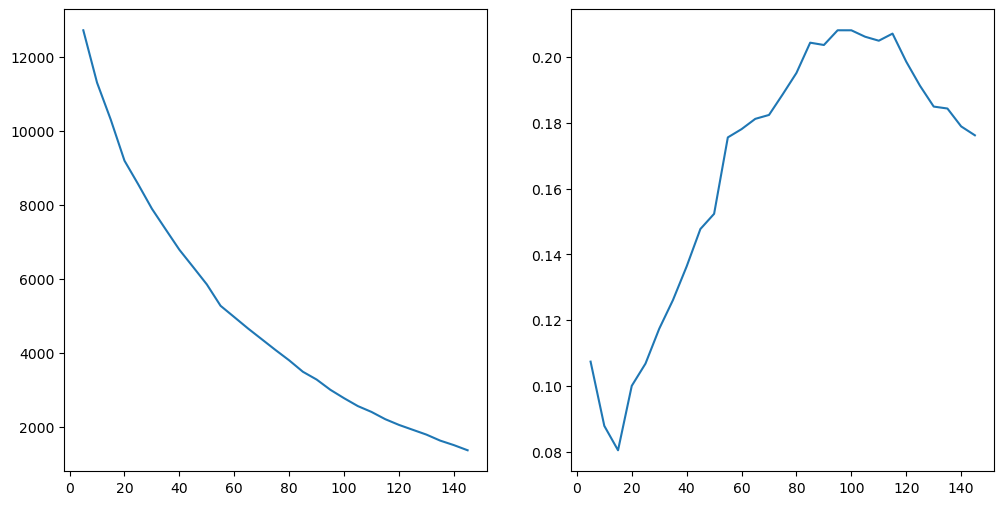

실루엣 최고점수의 인덱스: 95


In [5]:
# k 평균 군집화
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

k_range = range(5, 150, 5)
ellow = []
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(x_train_pca)

    silhouette_scores.append(silhouette_score(x_train_pca, km.labels_))
    ellow.append(km.inertia_)

fig, ax = plt.subplots(1,2,figsize=(12,6))
ax[0].plot(k_range, ellow)
ax[1].plot(k_range, silhouette_scores)
plt.show()

print(f'실루엣 최고점수의 인덱스: {k_range[np.argmax(silhouette_scores)]}')

(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

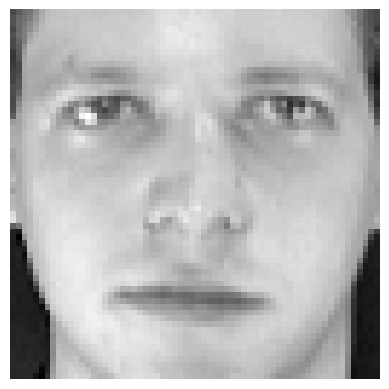

In [6]:
# 클러스터의 수 : 95
# 64 x 64
plt.imshow(X[0].reshape(64,64), cmap='gray')
plt.axis('off')

In [7]:
# kmeans로 군집을 구분
from sklearn.cluster import KMeans

k=40  # 전체 사람 40명
k_model = KMeans(n_clusters=k, random_state=42)
train_labels = k_model.fit_predict(x_train_pca)

c:\Users\Playdata\AppData\Local\miniconda3\envs\new_01\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [ ]:
cluster = 95
from sklearn.cluster import KMeans
km = KMeans(n_clusters=cluster,random_state=42)
km.fit(x_train_pca)

for c_label in np.unique(km.labels_):

    print(f'label = {c_label}')
    row_count = x_train[km.labels_ == c_label].shape[0]

    show_images = x_train[km.labels_ == c_label]

    for idx in range(row_count):
        plt.subplot(1,row_count,idx+1)
        plt.imshow(show_images[idx].reshape(64,64),cmap='gray')    
        plt.axis('off')
    plt.show()


In [14]:
# 분류기
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(n_estimators=200, random_state=42)
rfc.fit(x_train_pca, y_train)
rfc.score(x_test_pca, y_test)

0.90625

In [20]:
# 새로운 라벨링  k평균을 차원축소 도구로 사용

x_train_reduce = km.transform(x_train_pca) # (pca, cluster)
x_test_reduce = km.transform(x_test_pca)

clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(x_train_reduce, y_train)
clf.score(x_test_reduce, y_test)

0.73125

In [24]:
# 파이프라인 생성

from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
import warnings
warnings.filterwarnings("ignore")

pipeline = Pipeline([
    ('pca', PCA(n_components=0.99, random_state=42)),
    ('cluster', KMeans(random_state=42)),
    ('rfc',RandomForestClassifier(n_estimators=200, random_state=42))
])

k_range = range(5, 200, 5)
scores = []
for k in k_range:
    pipeline.set_params(cluster__n_clusters=k)
    pipeline.fit(x_train, y_train)
    scores.append(pipeline.score(x_test, y_test))

max_index = np.argmax(scores)
print(f'정확도:{np.max(scores)}, 클러스터 개수: {k_range[max_index]}')

정확도:0.78125, 클러스터 개수: 165


In [10]:
# 같은 사람끼리 묶였는지 확인
import numpy as np

def cluster_purity(y_true, y_pred):
    total = 0
    for cluster in np.unique(y_pred):
        idx = (y_pred == cluster)
        labels, counts = np.unique(y_true[idx], return_counts=True)
        total += counts.max()
    return total / len(y_true)

print("purity:", cluster_purity(y_train, train_labels))

purity: 0.6375


In [47]:
import numpy as np
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# ---------------------------
# 1. 데이터 로드
# ---------------------------
data = fetch_olivetti_faces()
X = data.data
y = data.target

# ---------------------------
# 2. train/test split
# ---------------------------
x_train, x_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.3, random_state=42
)

# ---------------------------
# 3. Pipeline
# ---------------------------
pipeline = Pipeline([
    ('pca', PCA()),
    ('svm', SVC())
])

# ---------------------------
# 4. 하이퍼파라미터 탐색
# ---------------------------
param_grid = {
    'pca__n_components': [50, 100, 150, 0.95, 0.99],
    'svm__kernel': ['rbf', 'linear'],
    'svm__C': [1, 10, 50, 100],
    'svm__gamma': ['scale', 0.001, 0.0001]  # rbf에서 중요
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    n_jobs=-1,
    verbose=1
)

# ---------------------------
# 5. 학습
# ---------------------------
grid.fit(x_train, y_train)

# ---------------------------
# 6. 결과
# ---------------------------
print("Best params:", grid.best_params_)
print("CV 최고 점수:", grid.best_score_)

# ---------------------------
# 7. 테스트 평가
# ---------------------------
best_model = grid.best_estimator_
y_pred = best_model.predict(x_test)

print("Test 정확도:", accuracy_score(y_test, y_pred))

Fitting 5 folds for each of 120 candidates, totalling 600 fits
Best params: {'pca__n_components': 50, 'svm__C': 50, 'svm__gamma': 0.001, 'svm__kernel': 'linear'}
CV 최고 점수: 0.9464285714285715
Test 정확도: 0.9666666666666667
